In [1]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('weight-height.csv') #working with height as no outliers in weight

In [7]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [9]:
df.shape

(10000, 3)

In [15]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [17]:
import seaborn as sns

<Axes: xlabel='Height', ylabel='Density'>

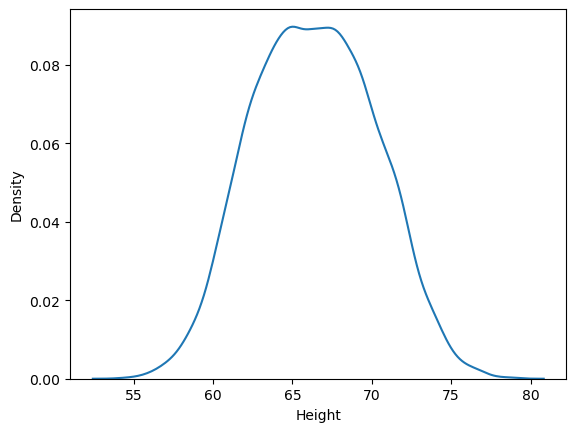

In [19]:
sns.kdeplot(df['Height'])

In [25]:
df['Height'].skew()

0.04936908937689031

<Axes: ylabel='Height'>

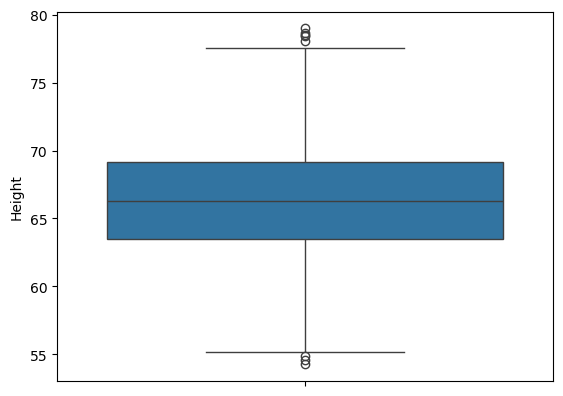

In [27]:
sns.boxplot(df['Height'])

In [29]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

74.7857900583366

In [31]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

58.13441158671655

In [33]:
df[(df['Height'] >= upper_limit) | (df['Height'] <= lower_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [35]:
new_df = df[(df['Height'] <= upper_limit) & (df['Height'] >= lower_limit)]

In [41]:
new_df['Height'].shape

(9800,)

In [43]:
new_df['Height'].describe()

count    9800.000000
mean       66.364366
std         3.645075
min        58.134496
25%        63.577162
50%        66.318070
75%        69.119896
max        74.785714
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

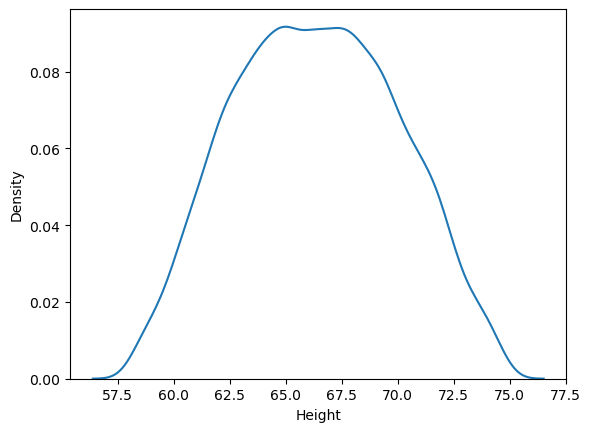

In [47]:
sns.kdeplot(new_df['Height'])

<Axes: ylabel='Height'>

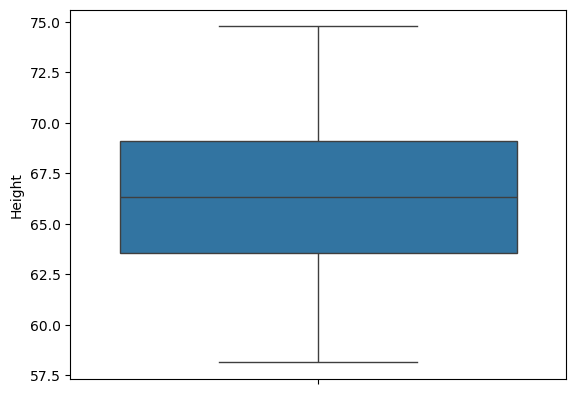

In [51]:
sns.boxplot(new_df['Height'])

In [55]:
#Capping -> Winsoriztion
df['Height'] = np.where(df['Height'] >= upper_limit,
         upper_limit,
         np.where(
         df['Height'] <= lower_limit,
         lower_limit,
         df['Height']
        )
)

In [57]:
df.shape

(10000, 3)

In [59]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Density'>

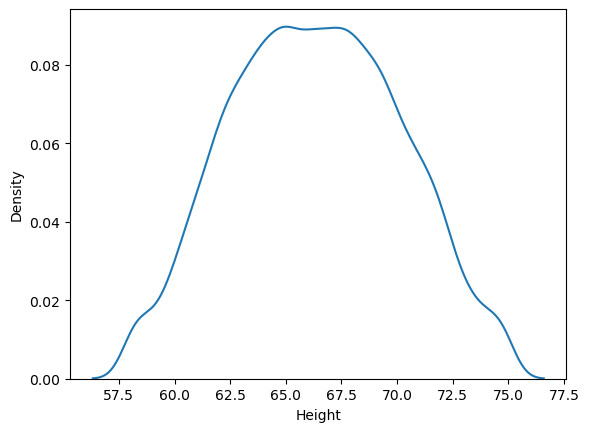

In [63]:
sns.kdeplot(df['Height'])

<Axes: ylabel='Height'>

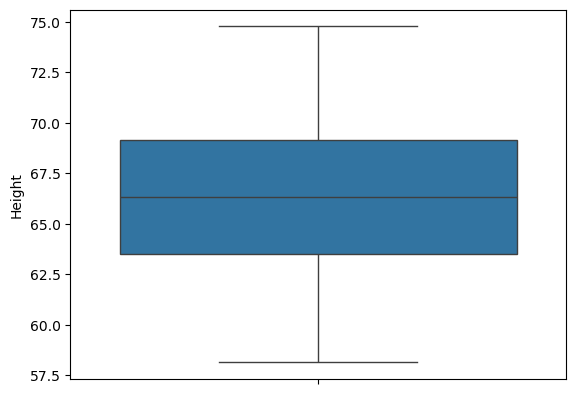

In [65]:
sns.boxplot(df['Height'])